# Direct Regression - Train & Evaluate

- Method: `direct` (ResNet18 backbone + FC(8) head, sigmoid + Wing Loss)
- Data: `data/smartdoc/gt_corners.csv` + `data/midv2020/gt_corners.csv` (combined via csv_path list)
- Scope: small-subset smoke test to verify the Trainer/Evaluator/DirectWrapper pipeline end-to-end.
  Full-dataset training is left to a later session (`scripts/train.py`, not yet implemented).

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [2]:
import matplotlib.pyplot as plt

from src.core.factory import get_dataset, get_wrapper
from src.data.dataloader import Dataloader
from src.core.trainer import Trainer, format_result
from src.core.evaluator import Evaluator
from src.utils.plot import show_history
from src.utils.io import save_model, load_model

## 1. Config

In [3]:
CSV_PATH = [
    os.path.join(PROJECT_ROOT, "data", "smartdoc", "gt_corners.csv"),
    os.path.join(PROJECT_ROOT, "data", "midv2020", "gt_corners.csv"),
]
IMAGE_SIZE = 224
BATCH_SIZE = 16
MAX_EPOCHS = 10
NUM_TRAIN_SAMPLES = 500
NUM_VALID_SAMPLES = 100
SEED = 42
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "direct_smoke")

## 2. Training

In [ ]:
train_dataset = get_dataset("train", CSV_PATH, image_size=IMAGE_SIZE, seed=SEED).subset(NUM_TRAIN_SAMPLES, seed=SEED)
valid_dataset = get_dataset("valid", CSV_PATH, image_size=IMAGE_SIZE, seed=SEED).subset(NUM_VALID_SAMPLES, seed=SEED)
train_loader = Dataloader("train", train_dataset, batch_size=BATCH_SIZE, seed=SEED)
valid_loader = Dataloader("valid", valid_dataset, batch_size=BATCH_SIZE, seed=SEED)

wrapper = get_wrapper("direct", backbone="resnet18")
print(f"Device: {wrapper.device}")

trainer = Trainer(wrapper, output_dir=OUTPUT_DIR)
history = trainer.fit(train_loader, valid_loader, max_epochs=MAX_EPOCHS)
trainer.save(history)
save_model(wrapper.model, os.path.join(OUTPUT_DIR, "model.pth"))

device cuda


[ 1/10] loss=0.5174 iou=0.3931 | loss=0.4403 iou=0.4111           
[ 2/10] loss=0.3753 iou=0.5115 | loss=0.3559 iou=0.5172           
[ 3/10] loss=0.3127 iou=0.5677 | loss=0.2506 iou=0.6373           
[ 4/10] loss=0.2920 iou=0.5790 | loss=0.2656 iou=0.6459           
[ 5/10] loss=0.2725 iou=0.6112 | loss=0.2361 iou=0.6766           
[ 6/10] loss=0.2510 iou=0.6398 | loss=0.2347 iou=0.6699           
[ 7/10] loss=0.2401 iou=0.6446 | loss=0.2234 iou=0.6567           
[ 8/10] loss=0.2341 iou=0.6571 | loss=0.2138 iou=0.6925           
[ 9/10] loss=0.2253 iou=0.6754 | loss=0.1579 iou=0.7591           
[10/10] loss=0.2172 iou=0.6722 | loss=0.1952 iou=0.7191           


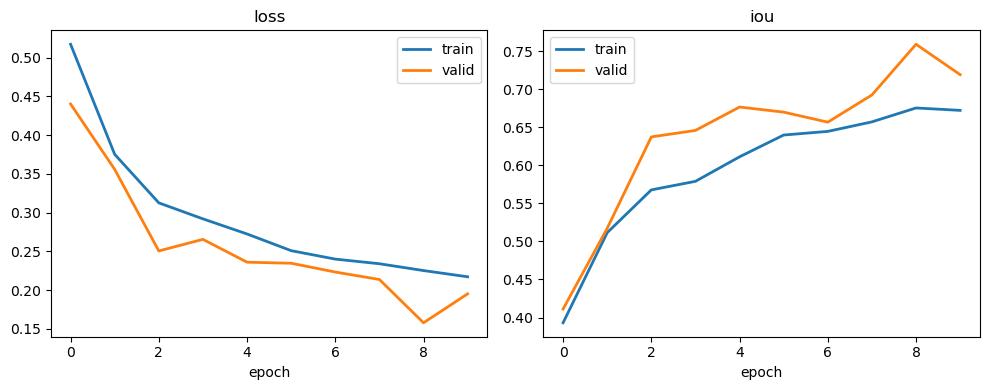

In [5]:
show_history(history)

## 3. Evaluation

In [9]:
evaluator = Evaluator(wrapper, output_dir=OUTPUT_DIR)
load_model(wrapper.model, os.path.join(OUTPUT_DIR, "model.pth"))

result = evaluator.evaluate(valid_loader)
evaluator.save(result)

iou=0.7191 mcd=0.0642 max_cd=0.1011 reproj_error=0.0642 pck=0.0000 sr=1.0000
